In [ ]:
import pandas as pd
import numpy as np

#loading the both datasets
raw_df = pd.read_csv("/content/Autism_Screening_Data_Combined.csv")       # raw textual answers
encoded_df = pd.read_csv("/content/Toddler Autism dataset July 2018.csv")  # already encoded 0/1 version

print("Raw Dataset:", raw_df.shape)
print("Encoded Dataset:", encoded_df.shape)

#preview
display(raw_df.head())
display(encoded_df.head())

#defining the Q-Chat mapping rules
def map_qchat_response(val, q_idx):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    #for A1–A9: Sometimes/Rarely/Never → 1, else 0
    if q_idx <= 9:
        if s in ['sometimes', 'rarely', 'rarly', 'never', 'no']:
            return 1
        else:
            return 0
    #for A10: Always/Usually/Sometimes → 1, else 0
    else:
        if s in ['always', 'usually', 'sometimes', 'yes']:
            return 1
        else:
            return 0

#apply the mapping on A1–A10
q_cols = [f"A{i}" for i in range(1,11)]
for i, col in enumerate(q_cols, start=1):
    raw_df[col + "_bin"] = raw_df[col].apply(lambda v: map_qchat_response(v, i))

#compute the score and class label
raw_df["Qchat_Score"] = raw_df[[c + "_bin" for c in q_cols]].sum(axis=1)
raw_df["Class_From_Raw"] = (raw_df["Qchat_Score"] > 3).astype(int)

print("\n Raw data converted using Q-Chat-10 rules.")
display(raw_df[q_cols + [c + "_bin" for c in q_cols] + ["Qchat_Score", "Class_From_Raw"]].head())

#compare with the encoded dataset
if "Class/ASD_Traits" in encoded_df.columns:
    encoded_label = encoded_df["Class/ASD_Traits"]
elif "Class" in encoded_df.columns:
    encoded_label = encoded_df["Class"]
else:
    encoded_label = None

if encoded_label is not None:
    #if same length, compare labels
    if len(raw_df) == len(encoded_df):
        diff = (raw_df["Class_From_Raw"] != encoded_label).sum()
        print(f"\nDifferences between raw-computed class and encoded class: {diff}/{len(raw_df)}")
    else:
        print("\nDatasets have different sizes — likely two separate samples (not row-aligned).")

#merge for the ML use
common_cols = [c for c in encoded_df.columns if c in raw_df.columns]
merged_df = pd.concat([raw_df, encoded_df], axis=0, ignore_index=True, sort=False)
print("\n Combined dataset created:", merged_df.shape)

#for quick verification
print("\nClass value counts:")
print(merged_df["Class_From_Raw"].value_counts(dropna=False))


Raw Dataset: (6075, 15)
Encoded Dataset: (1054, 19)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes



 Raw data converted using Q-Chat-10 rules.


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A3_bin,A4_bin,A5_bin,A6_bin,A7_bin,A8_bin,A9_bin,A10_bin,Qchat_Score,Class_From_Raw
0,1,1,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,1,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0



 Combined dataset created: (7129, 35)

Class value counts:
Class_From_Raw
0.0    6075
NaN    1054
Name: count, dtype: int64


In [ ]:
#create a unified target column for the 'Final_Class'

#first, copy the merged dataset
df = merged_df.copy()

#identify class columns from both datasets
if 'Class_From_Raw' in df.columns:
    df['Final_Class'] = df['Class_From_Raw']
if 'Class' in df.columns:
    #map YES/NO -> 1/0
    df['Class'] = df['Class'].astype(str).str.lower().map({'yes':1, 'no':0})
    #fill the NaNs in Final_Class using encoded dataset labels
    df['Final_Class'] = df['Final_Class'].fillna(df['Class'])
elif 'Class/ASD Traits' in df.columns:
    df['Class/ASD Traits'] = df['Class/ASD Traits'].astype(str).str.lower().map({'yes':1, 'no':0})
    df['Final_Class'] = df['Final_Class'].fillna(df['Class/ASD Traits'])

#for quick verification
print("\n Unified label column created:")
print(df['Final_Class'].value_counts(dropna=False))



 Unified label column created:
Final_Class
0.0    6075
NaN    1054
Name: count, dtype: int64


In [ ]:
#make a copy to avoid changes in merged_df
df = merged_df.copy()

#convert into the label columns to 1/0 numeric form
if 'Class' in df.columns:
    df['Class'] = df['Class'].astype(str).str.lower().map({'yes':1, 'no':0})
if 'Class/ASD Traits' in df.columns:
    df['Class/ASD Traits'] = df['Class/ASD Traits'].astype(str).str.lower().map({'yes':1, 'no':0})

#create a unified label column
df['Final_Class'] = df['Class_From_Raw']

#fill the NaNs using both possible class columns
if 'Class' in df.columns:
    df['Final_Class'] = df['Final_Class'].fillna(df['Class'])
if 'Class/ASD Traits' in df.columns:
    df['Final_Class'] = df['Final_Class'].fillna(df['Class/ASD Traits'])

#finally, dropping any rows still missing class (should be zero)
df = df.dropna(subset=['Final_Class'])

#convert the Final_Class to integer safely
df['Final_Class'] = df['Final_Class'].astype(int)

print("Fixed label column — no missing values remain:")
print(df['Final_Class'].value_counts())


Fixed label column — no missing values remain:
Final_Class
0    6075
Name: count, dtype: int64


In [ ]:
#steps
#start fresh from merged_df (your combined 7129x35 dataframe)
df = merged_df.copy()

#normalize all column names (remove spaces, slashes)
df.columns = df.columns.str.strip().str.replace('/', '_').str.replace(' ', '_')

#check available label columns
print("Columns related to class:\n", [c for c in df.columns if 'class' in c.lower()])

#convert possible class columns to numeric
for col in [c for c in df.columns if 'class' in c.lower()]:
    df[col] = df[col].astype(str).str.lower().map({'yes':1, 'no':0, '1':1, '0':0})

#create Final_Class intelligently from all possible columns
df['Final_Class'] = np.nan

#priority order: recomputed -> encoded
if 'Class_From_Raw' in df.columns:
    df['Final_Class'] = df['Class_From_Raw']
if 'Class_ASD_Traits' in df.columns:
    df['Final_Class'] = df['Final_Class'].fillna(df['Class_ASD_Traits'])
if 'Class' in df.columns:
    df['Final_Class'] = df['Final_Class'].fillna(df['Class'])

#drop rows without any class
df = df.dropna(subset=['Final_Class'])
df['Final_Class'] = df['Final_Class'].astype(int)

#verify results
print("\n Final label distribution:")
print(df['Final_Class'].value_counts())
print("\n Total rows after fixing:", len(df))


Columns related to class:
 ['Class', 'Class_From_Raw', 'Class_ASD_Traits']

 Final label distribution:
Final_Class
0    4597
1    2532
Name: count, dtype: int64

 Total rows after fixing: 7129


In [ ]:
feature_cols = [c for c in df.columns if c.startswith('A') and ('_bin' in c or c in [f"A{i}" for i in range(1,11)])]
X = df[feature_cols].fillna(0)
y = df['Final_Class']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model Evaluation:")
print(classification_report(y_test, y_pred))


Model Evaluation:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       920
           1       0.78      0.88      0.83       506

    accuracy                           0.87      1426
   macro avg       0.86      0.87      0.86      1426
weighted avg       0.88      0.87      0.87      1426



SHAP summary bar plot – strongest Q-Chat predictors of autism traits


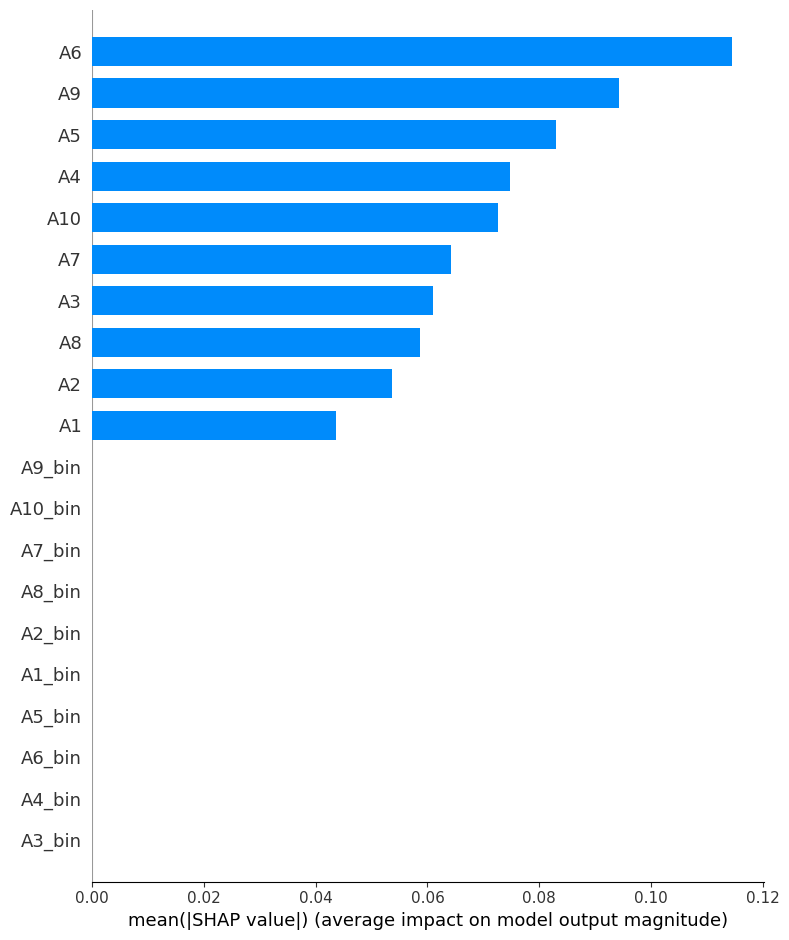

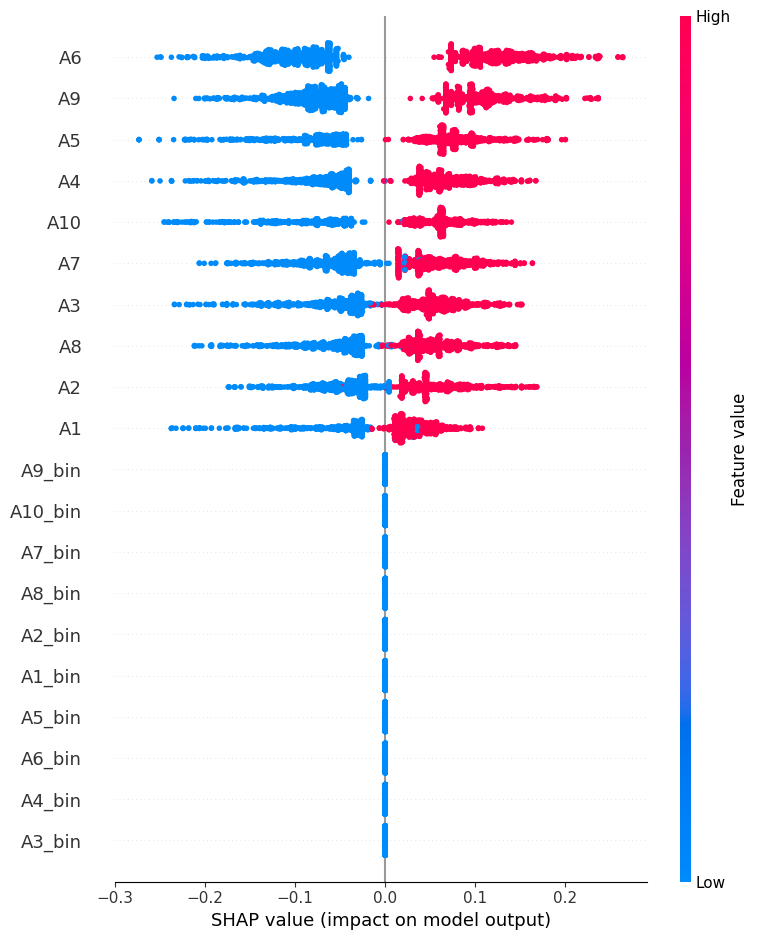

In [ ]:
#CPU-safe SHAP visualisation for your RandomForest model
import shap
import matplotlib.pyplot as plt

#ensure SHAP uses the pure-NumPy backend
shap.initjs()          # optional: enables interactive plots in Colab
explainer = shap.TreeExplainer(model, feature_perturbation="auto") # Changed to 'auto'
shap_values = explainer.shap_values(X_test)

#bar chart of overall feature importance
print("SHAP summary bar plot – strongest Q-Chat predictors of autism traits")
#corrected indexing: shap_values[:, :, 1] for class 1
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=True)

#detailed summary plot (value direction and magnitude)
#corrected indexing: shap_values[:, :, 1] for class 1
shap.summary_plot(shap_values[:, :, 1], X_test, show=True)

SHAP summary with full question labels


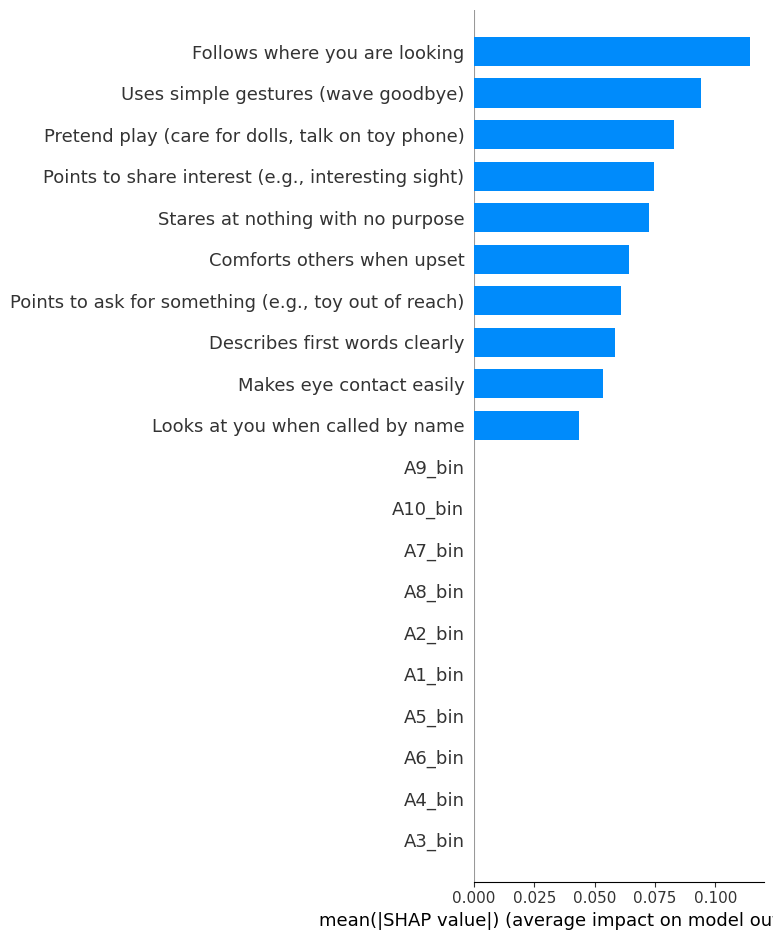

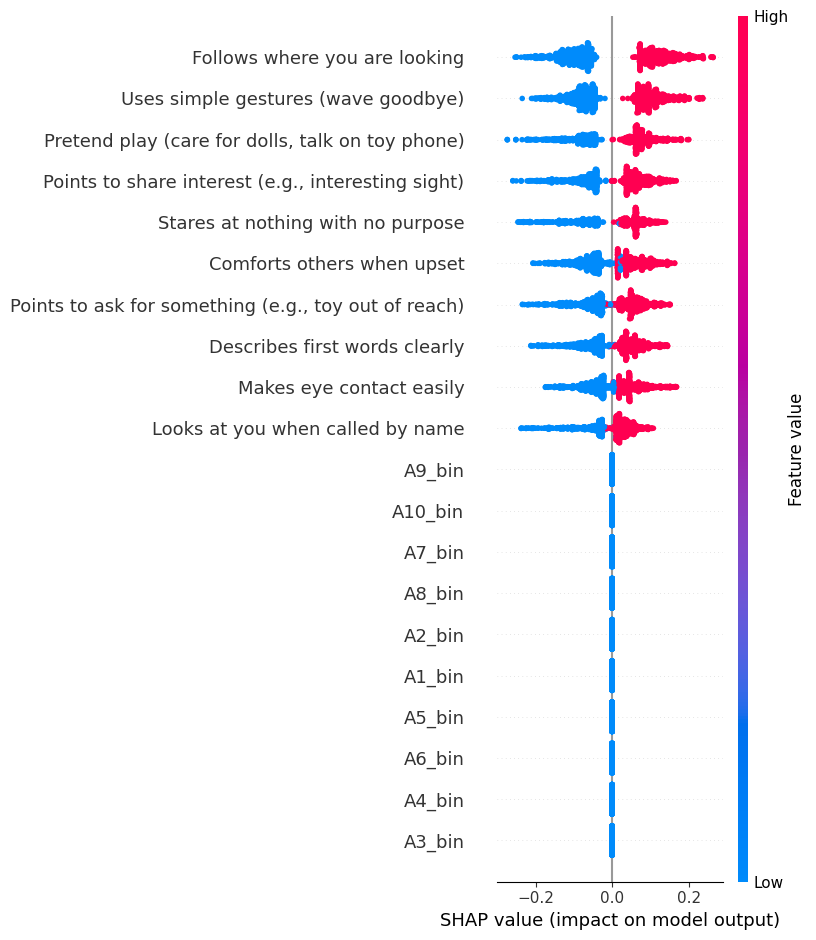

In [ ]:
#replace short codes with full Q-Chat question text

#mapping of A1–A10 → actual screening questions
qchat_labels = {
    "A1": "Looks at you when called by name",
    "A2": "Makes eye contact easily",
    "A3": "Points to ask for something (e.g., toy out of reach)",
    "A4": "Points to share interest (e.g., interesting sight)",
    "A5": "Pretend play (care for dolls, talk on toy phone)",
    "A6": "Follows where you are looking",
    "A7": "Comforts others when upset",
    "A8": "Describes first words clearly",
    "A9": "Uses simple gestures (wave goodbye)",
    "A10": "Stares at nothing with no purpose"
}

#rename columns in a copy of X_test
X_test_labeled = X_test.copy()
X_test_labeled = X_test_labeled.rename(columns=qchat_labels)

#re-draw SHAP plots with readable labels
print("SHAP summary with full question labels")
shap.summary_plot(shap_values[:, :, 1], X_test_labeled, plot_type="bar", show=True)

shap.summary_plot(shap_values[:, :, 1], X_test_labeled, show=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.898317   0.847784  0.869565  0.858537
3                  SVM  0.887097   0.816514  0.879447  0.846813
1        Decision Tree  0.874474   0.796733  0.867589  0.830653
4                  KNN  0.875175   0.802583  0.859684  0.830153
5              XGBoost  0.870266   0.786096  0.871542  0.826617
2        Random Forest  0.867461   0.777583  0.877470  0.824513


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:19:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


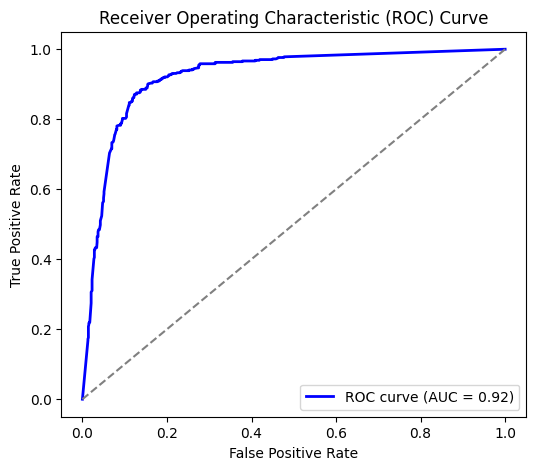

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
sample_index = 5  # choose a test sample
shap.initjs()
shap.force_plot(explainer.expected_value[1],
                shap_values[sample_index, :, 1],
                X_test_labeled.iloc[sample_index, :])